Configuracio´n incial

In [17]:
# FinTech Analytics — ETL desde Google Sheets (CSV públicos) -> CSVs para Power BI

import io, time, os
import numpy as np
import pandas as pd
import requests

# usamos las URLs PUBLICADAS (usando cada pestaña)
URL_TRANSACCIONES = "https://docs.google.com/spreadsheets/d/e/2PACX-1vSgxcxECvtRBbOHWRPdVl-MC3eQRZjONjR0XbvQjWGgNZnE158vAzdDVcJrc8ZYtA/pub?gid=677103559&single=true&output=csv"
URL_PRECIOS       = "https://docs.google.com/spreadsheets/d/e/2PACX-1vSgxcxECvtRBbOHWRPdVl-MC3eQRZjONjR0XbvQjWGgNZnE158vAzdDVcJrc8ZYtA/pub?gid=1177381725&single=true&output=csv"
URL_INDICES       = "https://docs.google.com/spreadsheets/d/e/2PACX-1vSgxcxECvtRBbOHWRPdVl-MC3eQRZjONjR0XbvQjWGgNZnE158vAzdDVcJrc8ZYtA/pub?gid=246080563&single=true&output=csv"
URL_METADATOS     = "https://docs.google.com/spreadsheets/d/e/2PACX-1vSgxcxECvtRBbOHWRPdVl-MC3eQRZjONjR0XbvQjWGgNZnE158vAzdDVcJrc8ZYtA/pub?gid=1693794780&single=true&output=csv"

OUT_DIR = "/content/out_es"
os.makedirs(OUT_DIR, exist_ok=True)

Utilidades de lectura robusta

In [18]:
def read_public_csv(url: str, parse_dates=None, decimal=".", retries=2, timeout=20):
    """
    Lee un CSV publicado en Google Sheets (URL '.../output=csv') con requests + pandas.
    - Añade cache-buster (&ts=...) para evitar caché intermedio.
    - Reintenta 'retries' varias veces si hay errores de red/HTTP.
    """
    last_err = None
    for attempt in range(retries + 1):
        try:
            u = url + f"&ts={int(time.time())}"
            resp = requests.get(u, timeout=timeout)
            resp.raise_for_status()
            df = pd.read_csv(io.StringIO(resp.text), parse_dates=parse_dates, decimal=decimal)
            df.columns = [c.strip().lower() for c in df.columns]
            return df
        except Exception as e:
            last_err = e
            time.sleep(1.2)
    raise RuntimeError(f"Fallo leyendo CSV desde {url} -> {type(last_err).__name__}: {last_err}")

def save_parquet(df: pd.DataFrame, name: str):
    path = f"{OUT_DIR}/{name}"
    df.to_parquet(path, engine="pyarrow", index=False)
    print("✔ Guardado:", path)


Cargar hojas y normalizar columnas

In [19]:
# Leer hojas
trans   = read_public_csv(URL_TRANSACCIONES, parse_dates=["fecha"])
precios = read_public_csv(URL_PRECIOS,       parse_dates=["fecha"])
indices = read_public_csv(URL_INDICES,       parse_dates=["fecha"])
try:
    metadatos = read_public_csv(URL_METADATOS)
except Exception as e:
    print("[WARN] Sin 'metadatos':", e)
    metadatos = pd.DataFrame()

# Mapear posibles nombres en inglés a español (por si acaso)
rename_trans = {
    "date":"fecha","account_id":"cuenta_id","type":"tipo",
    "quantity":"cantidad","price":"precio","fees":"comisiones",
    "fx_rate":"tipo_cambio","notes":"notas","asset_name":"nombre_activo","sector_name":"sector"
}
rename_precios = {"date":"fecha","close":"cierre"}
rename_indices = {"date":"fecha","benchmark":"indice","close":"cierre"}

trans.rename(columns={k:v for k,v in rename_trans.items() if k in trans.columns}, inplace=True)
precios.rename(columns={k:v for k,v in rename_precios.items() if k in precios.columns}, inplace=True)
indices.rename(columns={k:v for k,v in rename_indices.items() if k in indices.columns}, inplace=True)

# Tipos numéricos
for c in ["cantidad","precio","comisiones","tipo_cambio"]:
    if c in trans.columns:
        trans[c] = pd.to_numeric(trans[c], errors="coerce").fillna(0.0)

if "cierre" in precios.columns:
    precios["cierre"] = pd.to_numeric(precios["cierre"], errors="coerce").fillna(0.0)
if "cierre" in indices.columns:
    indices["cierre"] = pd.to_numeric(indices["cierre"], errors="coerce").fillna(0.0)

# Convención: VENTA => cantidad negativa (también soporta 'SELL')
if "tipo" in trans.columns and "cantidad" in trans.columns:
    mask_sell = trans["tipo"].astype(str).str.upper().str.strip().isin(["VENTA","SELL"])
    trans.loc[mask_sell, "cantidad"] *= -1

# Chequeo mínimo
req = {"fecha","cuenta_id","ticker","tipo","cantidad","precio"}
faltan = req - set(trans.columns)
if faltan:
    raise ValueError(f"Faltan columnas en 'transacciones': {faltan}")

print("Dimensiones:")
print("  transacciones:", trans.shape)
print("  precios:", precios.shape)
print("  indices:", indices.shape)


Dimensiones:
  transacciones: (79, 12)
  precios: (5337, 4)
  indices: (593, 4)


ETL: valorización, retornos, acumulado

In [20]:
# ETL: valorización + retornos seguros (vectorizado, sin groupby.apply)

# Orden temporal + cantidad acumulada por cuenta/ticker
trans = trans.sort_values(["cuenta_id","ticker","fecha"])
trans["cantidad_acum"] = trans.groupby(["cuenta_id","ticker"])["cantidad"].cumsum()

# Pivot de precios (fecha x ticker) con forward-fill
px = precios.pivot(index="fecha", columns="ticker", values="cierre").sort_index().ffill()

# Valorización diaria por cuenta/ticker (última cantidad del día)
valores = []
for cta, gcta in trans.groupby("cuenta_id"):
    for tkr, g in gcta.groupby("ticker"):
        q_day_last = g.set_index("fecha")["cantidad_acum"].groupby(level=0).last()
        q = q_day_last.reindex(px.index).ffill().fillna(0.0)
        p = px.get(tkr, pd.Series(index=px.index, dtype=float)).ffill().fillna(0.0)
        valores.append(pd.DataFrame({
            "fecha": px.index,
            "cuenta_id": cta,
            "ticker": tkr,
            "valor_posicion": q.values * p.values
        }))

posiciones = (pd.concat(valores, ignore_index=True)
              if valores else
              pd.DataFrame(columns=["fecha","cuenta_id","ticker","valor_posicion"]))

# Cartera diaria (suma por cuenta)
cartera = (posiciones.groupby(["fecha","cuenta_id"], as_index=False)["valor_posicion"]
           .sum()
           .rename(columns={"valor_posicion":"valor_cartera"})
           .sort_values(["cuenta_id","fecha"]))

# Retorno SEGURO (sin infinitos)
prev = cartera.groupby("cuenta_id")["valor_cartera"].shift()
cartera["retorno"] = (cartera["valor_cartera"] / prev - 1).where(prev > 0, 0.0)
cartera["retorno"] = cartera["retorno"].replace([np.inf, -np.inf], 0.0).fillna(0.0)

# Acumulado desde el primer día con capital > 0
cartera["acumulado"] = 1.0
bloques = []
for acc, g in cartera.groupby("cuenta_id"):
    g = g.copy()
    activos = g["valor_cartera"] > 0
    if activos.any():
        i0 = g.index[activos][0]
        g.loc[i0:, "acumulado"] = (1 + g.loc[i0:, "retorno"]).cumprod()
    bloques.append(g)
cartera = pd.concat(bloques).sort_values(["cuenta_id","fecha"])

print("Cartera (muestra):")
display(cartera.head(10))

print("\nPrimer día activo por cuenta:")
print(cartera[cartera["valor_cartera"]>0].groupby("cuenta_id")["fecha"].min())


Cartera (muestra):


,fecha,cuenta_id,valor_cartera,retorno,acumulado
0,2024-01-01,CTA-01,0.0,0.0,1.0
2,2024-01-02,CTA-01,0.0,0.0,1.0
4,2024-01-03,CTA-01,0.0,0.0,1.0
6,2024-01-04,CTA-01,0.0,0.0,1.0
8,2024-01-05,CTA-01,0.0,0.0,1.0
10,2024-01-06,CTA-01,0.0,0.0,1.0
12,2024-01-07,CTA-01,0.0,0.0,1.0
14,2024-01-08,CTA-01,0.0,0.0,1.0
16,2024-01-09,CTA-01,0.0,0.0,1.0
18,2024-01-10,CTA-01,0.0,0.0,1.0



Primer día activo por cuenta:
cuenta_id
CTA-01   2024-01-26
CTA-02   2024-01-07
Name: fecha, dtype: datetime64[us]


Exposición y Estadísticos (Media / Varianza)

In [21]:
# Exposición por ticker (valor promedio) + pesos por cuenta
exp_ticker = posiciones.groupby(["cuenta_id","ticker"], as_index=False)["valor_posicion"].mean()
exp_ticker.rename(columns={"valor_posicion":"valor_promedio"}, inplace=True)

# Sector si está en transacciones
if "sector" in trans.columns:
    sector_map = trans[["ticker","sector"]].drop_duplicates().set_index("ticker")["sector"]
    exp_ticker["sector"] = exp_ticker["ticker"].map(sector_map)
else:
    sector_map = None

# Exposición por sector
if sector_map is not None:
    exp_sector = exp_ticker.groupby(["cuenta_id","sector"], as_index=False)["valor_promedio"].sum()
else:
    exp_sector = exp_ticker.rename(columns={"ticker":"sector"})[["cuenta_id","sector","valor_promedio"]]

# Normalizar pesos por cuenta
def normaliza_pesos(df):
    outs = []
    for cta, g in df.groupby("cuenta_id"):
        total = g["valor_promedio"].sum()
        g = g.copy()
        g["peso"] = 0.0 if total == 0 else g["valor_promedio"] / total
        outs.append(g)
    return pd.concat(outs, ignore_index=True)

exp_ticker = normaliza_pesos(exp_ticker)
exp_sector = normaliza_pesos(exp_sector)

# Estadísticos (EXCLUYENDO días sin capital)
activos = cartera["valor_cartera"] > 0
estad_ret_cta = (cartera[activos]
                 .groupby("cuenta_id")["retorno"]
                 .agg(media_retorno="mean", varianza_retorno="var")
                 .reset_index())

estad_precio_tkr = (precios.groupby("ticker")["cierre"]
                    .agg(media_precio="mean", varianza_precio="var")
                    .reset_index())

if "comisiones" in trans.columns:
    estad_com_cta = (trans.groupby("cuenta_id")["comisiones"]
                     .agg(media_comision="mean", varianza_comision="var")
                     .reset_index())
else:
    estad_com_cta = pd.DataFrame(columns=["cuenta_id","media_comision","varianza_comision"])

estad_valor_cta = (cartera[activos].groupby("cuenta_id")["valor_cartera"]
                   .agg(media_valor_cartera="mean", varianza_valor_cartera="var")
                   .reset_index())

display(estad_ret_cta, estad_precio_tkr.head(), exp_sector.head())


,cuenta_id,media_retorno,varianza_retorno
0,CTA-01,0.053708,0.228561
1,CTA-02,0.077376,0.094816


,ticker,media_precio,varianza_precio
0,AAPL,2.932546,725.319767
1,AMD,7.308600,3306.967105
2,AVGO,2.059022,255.173875
3,CRM,1.485666,459.848189
4,GOOGL,1.617201,400.807609


,cuenta_id,sector,valor_promedio,peso
0,CTA-01,Hardware/Dispositivos,128.875211,0.127920
1,CTA-01,Internet/Redes Sociales,419.468803,0.416360
2,CTA-01,Internet/Servicios,69.374368,0.068860
3,CTA-01,Semiconductores,247.278246,0.245446
4,CTA-01,Software Empresarial,142.468803,0.141413


Comparativa Benchmark vs Portafolio

In [22]:
# índice y cartera densos, saneo completo, sin warnings

import numpy as np
import pandas as pd

# Índice densificado (calendario diario en el rango de la cartera)
rango_fechas = pd.date_range(cartera["fecha"].min(), cartera["fecha"].max(), freq="D")
idx_dense = (
    pd.DataFrame({"fecha": rango_fechas})
    .merge(indices[["fecha","cierre"]].copy(), on="fecha", how="left")
    .sort_values("fecha")
)

# Saneo del índice
idx_dense["cierre"] = pd.to_numeric(idx_dense["cierre"], errors="coerce")
idx_dense.loc[~(idx_dense["cierre"] > 0), "cierre"] = np.nan
idx_dense["cierre"] = idx_dense["cierre"].ffill().bfill()

ret_ind = idx_dense["cierre"].pct_change().replace([np.inf, -np.inf], np.nan).fillna(0.0)
idx_dense["accum_ind"] = (1.0 + ret_ind).cumprod()

# Comparativa por cuenta: densificar cartera, sanear, y rebasear el índice
rows = []
for cta, g in cartera.groupby("cuenta_id"):
    sub = g[g["valor_cartera"] > 0].copy()
    if sub.empty:
        continue

    # Densificar calendario de la cuenta (solo periodo activo)
    sub = sub.set_index("fecha").sort_index()
    sub = sub.reindex(pd.date_range(sub.index.min(), sub.index.max(), freq="D"))

    # Saneo de serie del portafolio
    sub["cuenta_id"] = sub["cuenta_id"].ffill().bfill()
    sub["retorno"] = pd.to_numeric(sub["retorno"], errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0.0)

    # Acumulado del portafolio sin NaN/inf
    sub["accum_portafolio"] = (1.0 + sub["retorno"]).cumprod()

    # Volver a columna 'fecha' y unir con índice densificado
    sub = sub.reset_index().rename(columns={"index": "fecha"})
    merged = sub.merge(idx_dense[["fecha","accum_ind"]], on="fecha", how="left").sort_values("fecha")

    # Rebase del índice al primer día activo de la cuenta
    acc_ind = pd.to_numeric(merged["accum_ind"], errors="coerce").replace([np.inf, -np.inf], np.nan).ffill().bfill()
    base = acc_ind.iloc[0] if np.isfinite(acc_ind.iloc[0]) and acc_ind.iloc[0] != 0 else 1.0
    merged["accum_ind_rebased"] = (acc_ind / base).fillna(1.0)

    rows.append(merged[["fecha","cuenta_id","accum_portafolio","accum_ind_rebased"]])

benchmark_vs_portafolio = (
    pd.concat(rows, ignore_index=True)
    if rows else
    pd.DataFrame(columns=["fecha","cuenta_id","accum_portafolio","accum_ind_rebased"])
)

# Validación rápida
print("NAs en portafolio:", benchmark_vs_portafolio["accum_portafolio"].isna().sum(),
      "| NAs en índice:", benchmark_vs_portafolio["accum_ind_rebased"].isna().sum())

display(benchmark_vs_portafolio.head(15))

NAs en portafolio: 0 | NAs en índice: 0


,fecha,cuenta_id,accum_portafolio,accum_ind_rebased
0,2024-01-26,CTA-01,1.0,1.0
1,2024-01-27,CTA-01,1.0,1.0
2,2024-01-28,CTA-01,1.0,1.0
3,2024-01-29,CTA-01,1.0,1.0
4,2024-01-30,CTA-01,1.0,1.0
5,2024-01-31,CTA-01,1.0,1.0
6,2024-02-01,CTA-01,1.0,1.0
7,2024-02-02,CTA-01,1.0,1.0
8,2024-02-03,CTA-01,1.0,1.0
9,2024-02-04,CTA-01,1.0,1.0


Exportar CSVs para Power BI

In [23]:
save_parquet(cartera, "cartera_diaria.parquet")                       # fecha, cuenta_id, valor_cartera, retorno, acumulado
save_parquet(posiciones, "posiciones_diarias.parquet")                 # fecha, cuenta_id, ticker, valor_posicion
save_parquet(exp_ticker[["cuenta_id","ticker","valor_promedio","peso"]], "exposicion_ticker.parquet")
save_parquet(exp_sector[["cuenta_id","sector","valor_promedio","peso"]], "exposicion_sector.parquet")

save_parquet(estad_ret_cta, "estadisticos_retorno_cuenta.parquet")     # media/varianza del retorno diario
save_parquet(estad_precio_tkr, "estadisticos_precio_ticker.parquet")   # media/varianza de precios por ticker
save_parquet(estad_com_cta, "estadisticos_comisiones_cuenta.parquet")
save_parquet(estad_valor_cta, "estadisticos_valor_cartera.parquet")
save_parquet(benchmark_vs_portafolio, "benchmark_vs_portafolio.parquet")


✔ Guardado: /content/out_es/cartera_diaria.csv
✔ Guardado: /content/out_es/posiciones_diarias.csv
✔ Guardado: /content/out_es/exposicion_ticker.csv
✔ Guardado: /content/out_es/exposicion_sector.csv
✔ Guardado: /content/out_es/estadisticos_retorno_cuenta.csv
✔ Guardado: /content/out_es/estadisticos_precio_ticker.csv
✔ Guardado: /content/out_es/estadisticos_comisiones_cuenta.csv
✔ Guardado: /content/out_es/estadisticos_valor_cartera.csv
✔ Guardado: /content/out_es/benchmark_vs_portafolio.csv


Chequeos rápidos

In [24]:
# Sin duplicados fecha+cuenta en cartera
assert cartera[["fecha","cuenta_id"]].duplicated().sum() == 0, "Duplicados en cartera (fecha+cuenta_id)."
# NAs clave
assert not cartera["valor_cartera"].isna().any(), "NA en valor_cartera."
assert not posiciones["valor_posicion"].isna().any(), "NA en valor_posicion."

print("OK: ETL completado. CSVs listos en:", OUT_DIR)


OK: ETL completado. CSVs listos en: /content/out_es


# **Gráficos estadísticos**

Resúmenes por cuenta y período (mensual) + export

In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PLOTS_DIR = "/content/out_es/plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

# Crear columna Periodo (AAA-MM) en cartera
cartera["Periodo"] = cartera["fecha"].dt.to_period("M").astype(str)

# Resumen mensual por cuenta (similar a tu ejemplo, pero financiero)
resumen_mensual = (cartera[cartera["valor_cartera"]>0]
                   .groupby(["cuenta_id","Periodo"])["retorno"]
                   .agg(promedio_retorno="mean",
                        minimo_retorno="min",
                        maximo_retorno="max",
                        dias_con_datos="count")
                   ).reset_index()

# Exportar
resumen_mensual.to_parquet(f"{OUT_DIR}/resumen_mensual_por_cuenta.parquet", index=False)
try:
    resumen_mensual.to_excel(f"{OUT_DIR}/resumen_mensual_por_cuenta.xlsx", index=False)
except Exception as e:
    print("[INFO] Para Excel, instala openpyxl si lo necesitas:", e)

print("OK resumen mensual:", resumen_mensual.head(5))


OK resumen mensual:   cuenta_id  Periodo  promedio_retorno  minimo_retorno  maximo_retorno  \
0    CTA-01  2024-01          0.000000        0.000000         0.00000   
1    CTA-01  2024-02          0.000000        0.000000         0.00000   
2    CTA-01  2024-03         -0.132672       -0.663358         0.00000   
3    CTA-01  2024-04          1.167595        0.000000         2.33519   
4    CTA-01  2024-05          0.000000        0.000000         0.00000   

   dias_con_datos  
0               1  
1               1  
2               5  
3               2  
4               3  


Retorno promedio mensual por cuenta - en barras

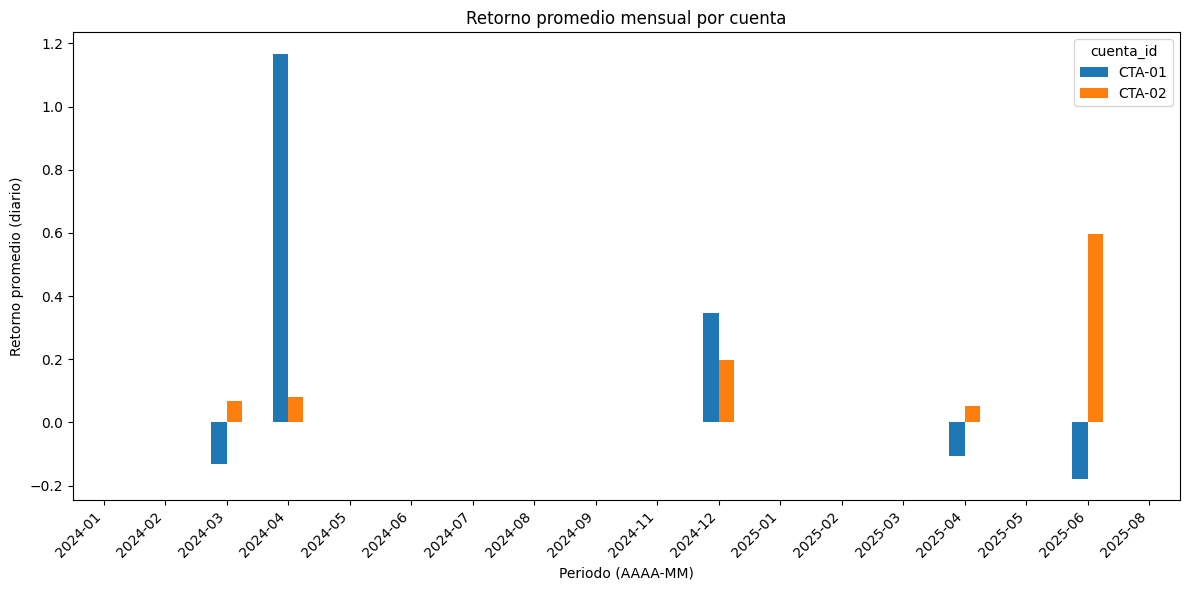

In [26]:
# Pivot para gráfico
pivot_prom = resumen_mensual.pivot(index="Periodo", columns="cuenta_id", values="promedio_retorno").fillna(0)

plt.figure(figsize=(12, 6))
pivot_prom.plot(kind="bar", ax=plt.gca())
plt.title("Retorno promedio mensual por cuenta")
plt.xlabel("Periodo (AAAA-MM)")
plt.ylabel("Retorno promedio (diario)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/retorno_promedio_mensual_por_cuenta.png", dpi=150)
plt.show()


Histograma de retornos diarios por cuenta

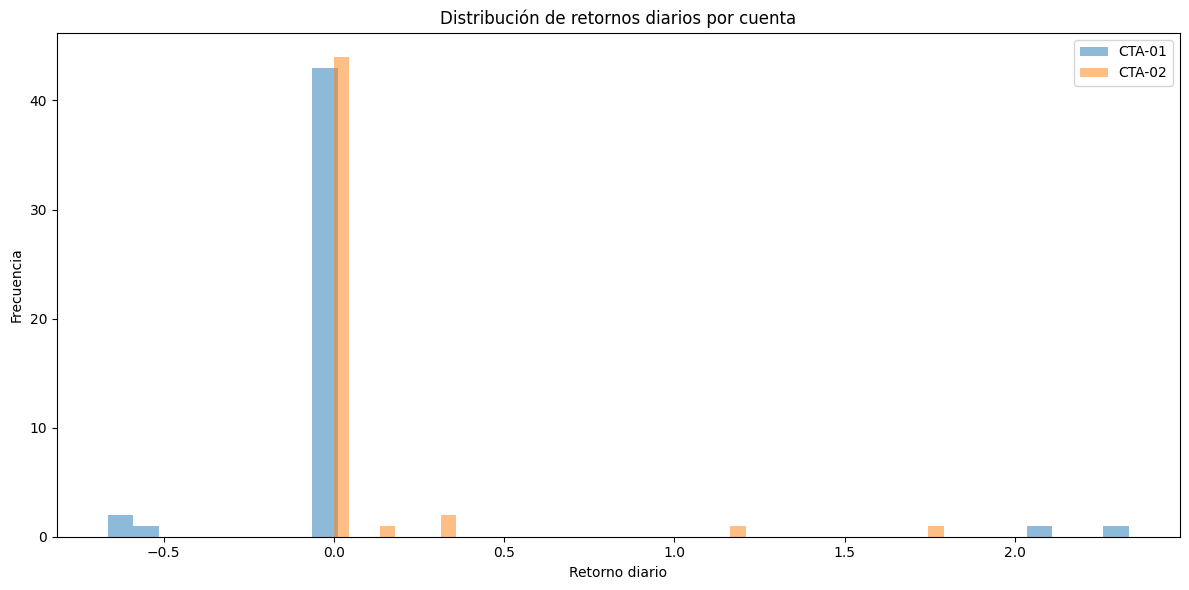

In [27]:
plt.figure(figsize=(12, 6))
for cta, g in cartera[cartera["valor_cartera"]>0].groupby("cuenta_id"):
    # hist por cuenta (transparencia ligera evitando especificar colores)
    plt.hist(g["retorno"].dropna().values, bins=40, alpha=0.5, label=f"{cta}")
plt.title("Distribución de retornos diarios por cuenta")
plt.xlabel("Retorno diario")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/hist_retornos_por_cuenta.png", dpi=150)
plt.show()


Volatilidad móvil (21 días) anualizada

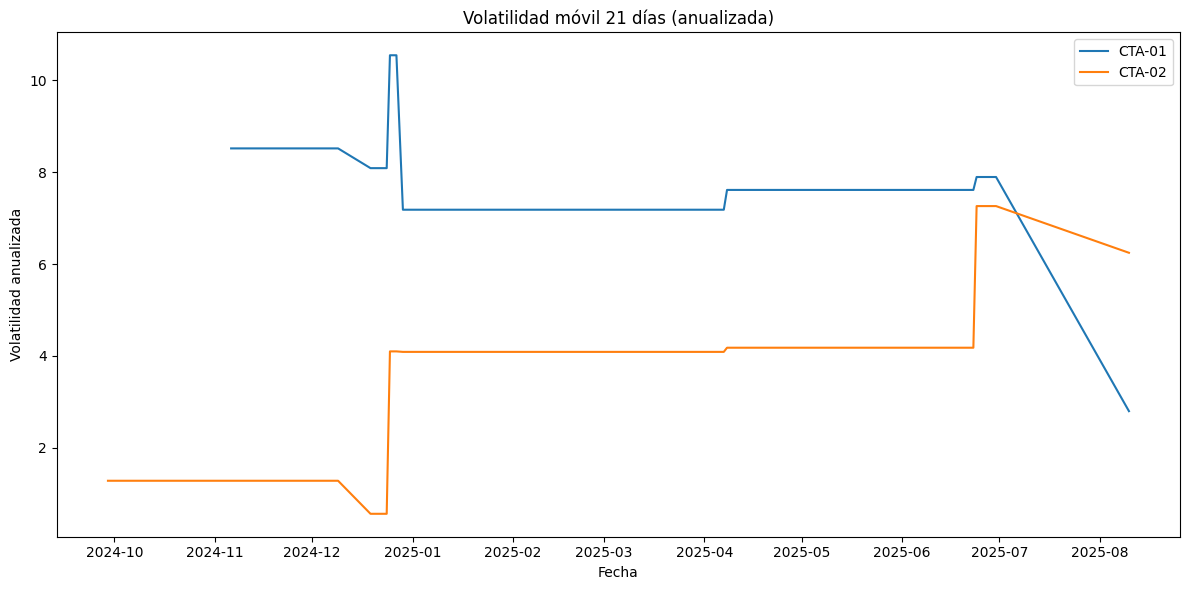

In [28]:
plt.figure(figsize=(12, 6))
for cta, g in cartera.groupby("cuenta_id"):
    sub = g[g["valor_cartera"]>0].copy()
    sub["vol_21d_ann"] = sub["retorno"].rolling(21).std(ddof=1) * np.sqrt(252)
    plt.plot(sub["fecha"], sub["vol_21d_ann"], label=cta)
plt.title("Volatilidad móvil 21 días (anualizada)")
plt.xlabel("Fecha")
plt.ylabel("Volatilidad anualizada")
plt.legend()
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/vol_rolling_21d.png", dpi=150)
plt.show()


In [29]:
import os, io, time, json, math
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

BASE = os.getcwd()
OUT  = BASE
FIG  = os.path.join(BASE, "figuras")
os.makedirs(FIG, exist_ok=True)

URLS = {
 "transacciones": "https://docs.google.com/spreadsheets/d/e/2PACX-1vSgxcxECvtRBbOHWRPdVl-MC3eQRZjONjR0XbvQjWGgNZnE158vAzdDVcJrc8ZYtA/pub?gid=677103559&single=true&output=csv",
 "precios":       "https://docs.google.com/spreadsheets/d/e/2PACX-1vSgxcxECvtRBbOHWRPdVl-MC3eQRZjONjR0XbvQjWGgNZnE158vAzdDVcJrc8ZYtA/pub?gid=1177381725&single=true&output=csv",
 "indices":       "https://docs.google.com/spreadsheets/d/e/2PACX-1vSgxcxECvtRBbOHWRPdVl-MC3eQRZjONjR0XbvQjWGgNZnE158vAzdDVcJrc8ZYtA/pub?gid=246080563&single=true&output=csv",
 "metadatos":     "https://docs.google.com/spreadsheets/d/e/2PACX-1vSgxcxECvtRBbOHWRPdVl-MC3eQRZjONjR0XbvQjWGgNZnE158vAzdDVcJrc8ZYtA/pub?gid=1693794780&single=true&output=csv",
}

XLSX = os.path.join(BASE,"fintech_analytics_pro_es.xlsx")

def try_read_excel(xlsx):
    try:
        import openpyxl  # si no hay, lanzará excepción y haremos fallback
        tx  = pd.read_excel(xlsx, sheet_name="transacciones")
        px  = pd.read_excel(xlsx, sheet_name="precios")
        idx = pd.read_excel(xlsx, sheet_name="indices")
        meta= pd.read_excel(xlsx, sheet_name="metadatos")
        return tx, px, idx, meta
    except Exception as e:
        return None

def read_from_urls(urls):
    import requests
    def fetch(u):
        r = requests.get(u, timeout=30)
        r.raise_for_status()
        return pd.read_csv(io.BytesIO(r.content))
    return fetch(urls["transacciones"]), fetch(urls["precios"]), fetch(urls["indices"]), fetch(urls["metadatos"])

# Carga con fallback: XLSX -> URLs -> CSV locales
loaded = try_read_excel(XLSX)
if loaded is None:
    try:
        loaded = read_from_urls(URLS)
    except Exception:
        # último recurso: usa los CSV locales si existen
        tx  = pd.read_csv(os.path.join(BASE,"transacciones.csv"))
        px  = pd.read_csv(os.path.join(BASE,"precios.csv"))
        idx = pd.read_csv(os.path.join(BASE,"indices.csv"))
        meta= pd.read_csv(os.path.join(BASE,"metadatos.csv"))
        loaded = (tx, px, idx, meta)

tx, px, idx, meta = loaded

# Tipos y limpieza mínimos
tx["fecha"] = pd.to_datetime(tx["fecha"])
px["fecha"] = pd.to_datetime(px["fecha"])
idx["fecha"]= pd.to_datetime(idx["fecha"])
tx["cantidad"]  = pd.to_numeric(tx["cantidad"], errors="coerce").fillna(0.0)
tx["precio"]    = pd.to_numeric(tx["precio"], errors="coerce").fillna(0.0)
tx["comisiones"]= pd.to_numeric(tx.get("comisiones",0.0), errors="coerce").fillna(0.0)
px["cierre"]    = pd.to_numeric(px["cierre"], errors="coerce")

# Inventario acumulado por cuenta/ticker
tx["signo"] = np.where(tx["tipo"].astype(str).str.upper().str.contains("VENTA"), -1, 1)
tx["cantidad_signed"] = tx["cantidad"] * tx["signo"]

# Resample diario y cálculo del acumulado directo
inv = (tx.set_index("fecha")
         .groupby(["cuenta_id", "ticker"])["cantidad_signed"]
         .resample("D").sum()
         .reset_index())

inv["cantidad"] = inv.groupby(["cuenta_id", "ticker"])["cantidad_signed"].cumsum()

# Valorización diaria (posiciones_diarias)
px_latest = px[["fecha","ticker","cierre"]]
pos = inv.merge(px_latest, on=["fecha","ticker"], how="left")
pos["valor"] = pos["cantidad"]*pos["cierre"]
pos.to_parquet(os.path.join(OUT,"posiciones_diarias.parquet"), index=False)

# Cartera diaria por cuenta
cartera = (pos.groupby(["fecha","cuenta_id"],as_index=False)["valor"].sum()
             .rename(columns={"valor":"valor_cartera"}))
cartera = cartera.sort_values(["cuenta_id","fecha"])
cartera["retorno"] = (cartera.groupby("cuenta_id")["valor_cartera"]
                      .pct_change(fill_method=None).replace([np.inf,-np.inf], np.nan).fillna(0.0))
cartera["acumulado"] = (1.0 + cartera["retorno"]).groupby(cartera["cuenta_id"]).cumprod()
cartera.to_parquet(os.path.join(OUT,"cartera_diaria.parquet"), index=False)

# Índice densificado y rebase
idx = idx.sort_values("fecha").copy()
idx["cierre"] = pd.to_numeric(idx["cierre"], errors="coerce")
idx["ret_ind"] = idx["cierre"].pct_change(fill_method=None).replace([np.inf,-np.inf], np.nan).fillna(0.0)
idx["accum_ind"]= (1.0 + idx["ret_ind"]).cumprod()

rows = []
for cta, g in cartera.groupby("cuenta_id"):
    sub = g[g["valor_cartera"]>0].copy()
    if sub.empty:
        continue
    m = sub.merge(idx[["fecha","accum_ind"]], on="fecha", how="left").sort_values("fecha")
    acc_ind = pd.to_numeric(m["accum_ind"], errors="coerce").ffill().bfill()
    base = acc_ind.iloc[0] if np.isfinite(acc_ind.iloc[0]) and acc_ind.iloc[0]!=0 else 1.0
    m["accum_ind_rebased"] = (acc_ind / base).fillna(1.0)
    rows.append(m[["fecha","cuenta_id","acumulado","accum_ind_rebased"]]
                .rename(columns={"acumulado":"accum_portafolio"}))
bench = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=["fecha","cuenta_id","accum_portafolio","accum_ind_rebased"])
bench.to_parquet(os.path.join(OUT,"benchmark_vs_portafolio.parquet"), index=False)

# Exposición sectorial (promedio ponderado)
if "sector" in pos.columns:
    expo_sector = (pos.groupby(["fecha","sector"],as_index=False)["valor"].sum())
    expo_sector["peso"] = expo_sector.groupby("fecha")["valor"].transform(lambda s: s/s.sum())
    expo_sector.groupby("sector",as_index=False)[["peso","valor"]].mean().to_parquet(os.path.join(OUT,"exposicion_sector.parquet"), index=False)

# Estadísticos varios (ejemplos)
(cart_eta := cartera.groupby("cuenta_id")["retorno"]
            .agg(media="mean", var="var").reset_index()
).to_parquet(os.path.join(OUT,"estadisticos_retorno_cuenta.parquet"), index=False)

# Figuras rápidas (reusa lógica del script de solo para figuras xd)
import subprocess, sys
subprocess.run([sys.executable, os.path.join(BASE,"make_figs_from_csv.py")], check=False)

print("Artefactos y figuras listos.")

Artefactos y figuras listos.
